# Proyek Machine Learning: Klasifikasi Kualitas Air (Water Potability)

**Mata Kuliah:** Machine Learning  
**Topik:** Klasifikasi  
**Dataset:** Water Potability Dataset (Kaggle)  
**Tujuan:** Memprediksi apakah air layak minum (Potable) atau tidak berdasarkan parameter kualitas air.
**Kelompok:** 3
**Anggota Kelompok:** 
- Muhammad Axel Savero Fikri (1313623004)
- Muhammad Adani Faza (1313623027)
- Andhika Dwiputra Soetjadi (1313623053) 

---

## 1. Data dan Eksplorasi Data (EDA)

Pada tahap ini, kita akan memuat dataset, memahami struktur data, menampilkan statistik deskriptif, serta melakukan visualisasi untuk menemukan pola dan anomali dalam data.

### 1.1 Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan. Kita menggunakan:
- **Pandas & NumPy** untuk manipulasi data
- **Matplotlib & Seaborn** untuk visualisasi
- **Scikit-Learn** untuk preprocessing, pemodelan, dan evaluasi

In [1]:
# ============================================================
# Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-Learn: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-Learn: Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Scikit-Learn: Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Konfigurasi tampilan
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


### 1.2 Memuat Dataset

Dataset `water_potability.csv` berisi 10 kolom parameter kualitas air. Kolom target adalah `Potability` yang bernilai:
- **1** = Air layak minum (Potable)
- **0** = Air tidak layak minum (Not Potable)

In [2]:
# ============================================================
# Memuat Dataset
# ============================================================
df = pd.read_csv('water_potability.csv')

# Menampilkan 5 baris pertama
print('=' * 60)
print('PREVIEW DATA (5 BARIS PERTAMA)')
print('=' * 60)
df.head()

PREVIEW DATA (5 BARIS PERTAMA)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [3]:
# Dimensi dataset
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Jumlah fitur   : {df.shape[1] - 1}')
print(f'Kolom target   : Potability')
print(f'\nDaftar kolom   : {list(df.columns)}')

Jumlah baris   : 3276
Jumlah kolom   : 10
Jumlah fitur   : 9
Kolom target   : Potability

Daftar kolom   : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [4]:
# Informasi tipe data dan non-null count
print('=' * 60)
print('INFORMASI DATASET')
print('=' * 60)
df.info()

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


### 1.3 Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum tentang distribusi setiap fitur, mencakup Mean, Median (50%), Standar Deviasi, nilai minimum dan maksimum, serta kuartil.

In [5]:
# ============================================================
# Statistik Deskriptif
# ============================================================
desc_stats = df.describe().T

# Menambahkan kolom Median secara eksplisit
desc_stats['median'] = df.median(numeric_only=True)

# Mengurutkan kolom agar lebih informatif
desc_stats = desc_stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print('=' * 60)
print('STATISTIK DESKRIPTIF')
print('=' * 60)
desc_stats

STATISTIK DESKRIPTIF


,count,mean,median,std,min,25%,50%,75%,max
ph,2785.0000,7.0808,7.0368,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000
Hardness,3276.0000,196.3695,196.9676,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240
Solids,3276.0000,22014.0925,20927.8336,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960
Chloramines,3276.0000,7.1223,7.1303,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270
Sulfate,2495.0000,333.7758,333.0735,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306
Conductivity,3276.0000,426.2051,421.8850,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426
Organic_carbon,3276.0000,14.2850,14.2183,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000
Trihalomethanes,3114.0000,66.3963,66.6225,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000
Turbidity,3276.0000,3.9668,3.9550,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390
Potability,3276.0000,0.3901,0.0000,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000


### 1.4 Analisis Missing Values

Missing values dapat memengaruhi performa model. Kita perlu mengidentifikasi kolom mana yang memiliki data hilang, berapa jumlah dan persentasenya.

In [6]:
# ============================================================
# Analisis Missing Values
# ============================================================
missing_df = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Jumlah Missing', ascending=False)

print('=' * 60)
print('MISSING VALUES')
print('=' * 60)
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Total data points   : {df.shape[0] * df.shape[1]}')

MISSING VALUES
                 Jumlah Missing  Persentase (%)
Sulfate                     781         23.8400
ph                          491         14.9900
Trihalomethanes             162          4.9500
Hardness                      0          0.0000
Chloramines                   0          0.0000
Solids                        0          0.0000
Conductivity                  0          0.0000
Organic_carbon                0          0.0000
Turbidity                     0          0.0000
Potability                    0          0.0000

Total missing values: 1434
Total data points   : 32760


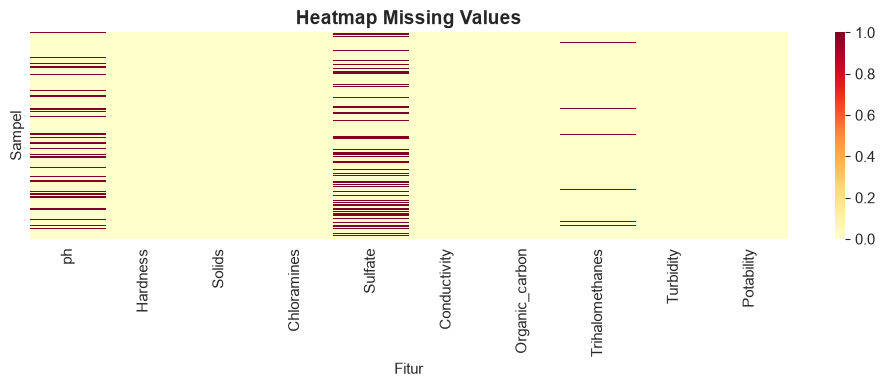

In [7]:
# Visualisasi Missing Values dengan Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
ax.set_title('Heatmap Missing Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Fitur')
ax.set_ylabel('Sampel')
plt.tight_layout()
plt.show()

### 1.5 Distribusi Target (Potability)

Penting untuk memeriksa keseimbangan kelas pada variabel target. Jika distribusi tidak seimbang (imbalanced), hal ini dapat memengaruhi performa model dan metrik evaluasi yang digunakan.

Distribusi Kelas Target:
  Kelas 0 (Tidak Layak Minum): 1998 sampel (61.0%)
  Kelas 1 (Layak Minum)      : 1278 sampel (39.0%)
  Rasio                       : 1 : 1.56


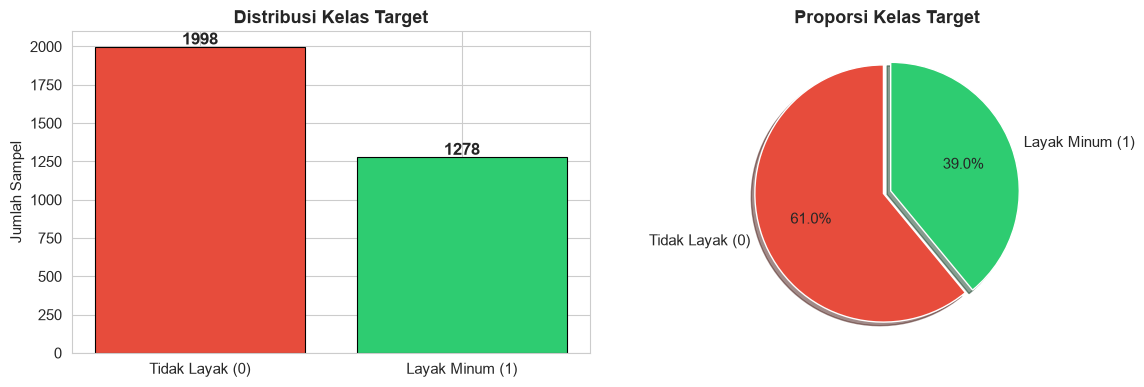

In [8]:
# ============================================================
# Distribusi Target
# ============================================================
target_counts = df['Potability'].value_counts()
target_pct = df['Potability'].value_counts(normalize=True) * 100

print('Distribusi Kelas Target:')
print(f'  Kelas 0 (Tidak Layak Minum): {target_counts[0]} sampel ({target_pct[0]:.1f}%)')
print(f'  Kelas 1 (Layak Minum)      : {target_counts[1]} sampel ({target_pct[1]:.1f}%)')
print(f'  Rasio                       : 1 : {target_counts[0]/target_counts[1]:.2f}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(['Tidak Layak (0)', 'Layak Minum (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
                 f'{count}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Layak (0)', 'Layak Minum (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=[0.03, 0.03], shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.6 Visualisasi Distribusi Fitur (Histogram)

Histogram menunjukkan distribusi frekuensi setiap fitur. Dengan membedakan warna berdasarkan kelas target, kita dapat melihat apakah ada perbedaan distribusi antara air layak minum dan tidak layak minum.

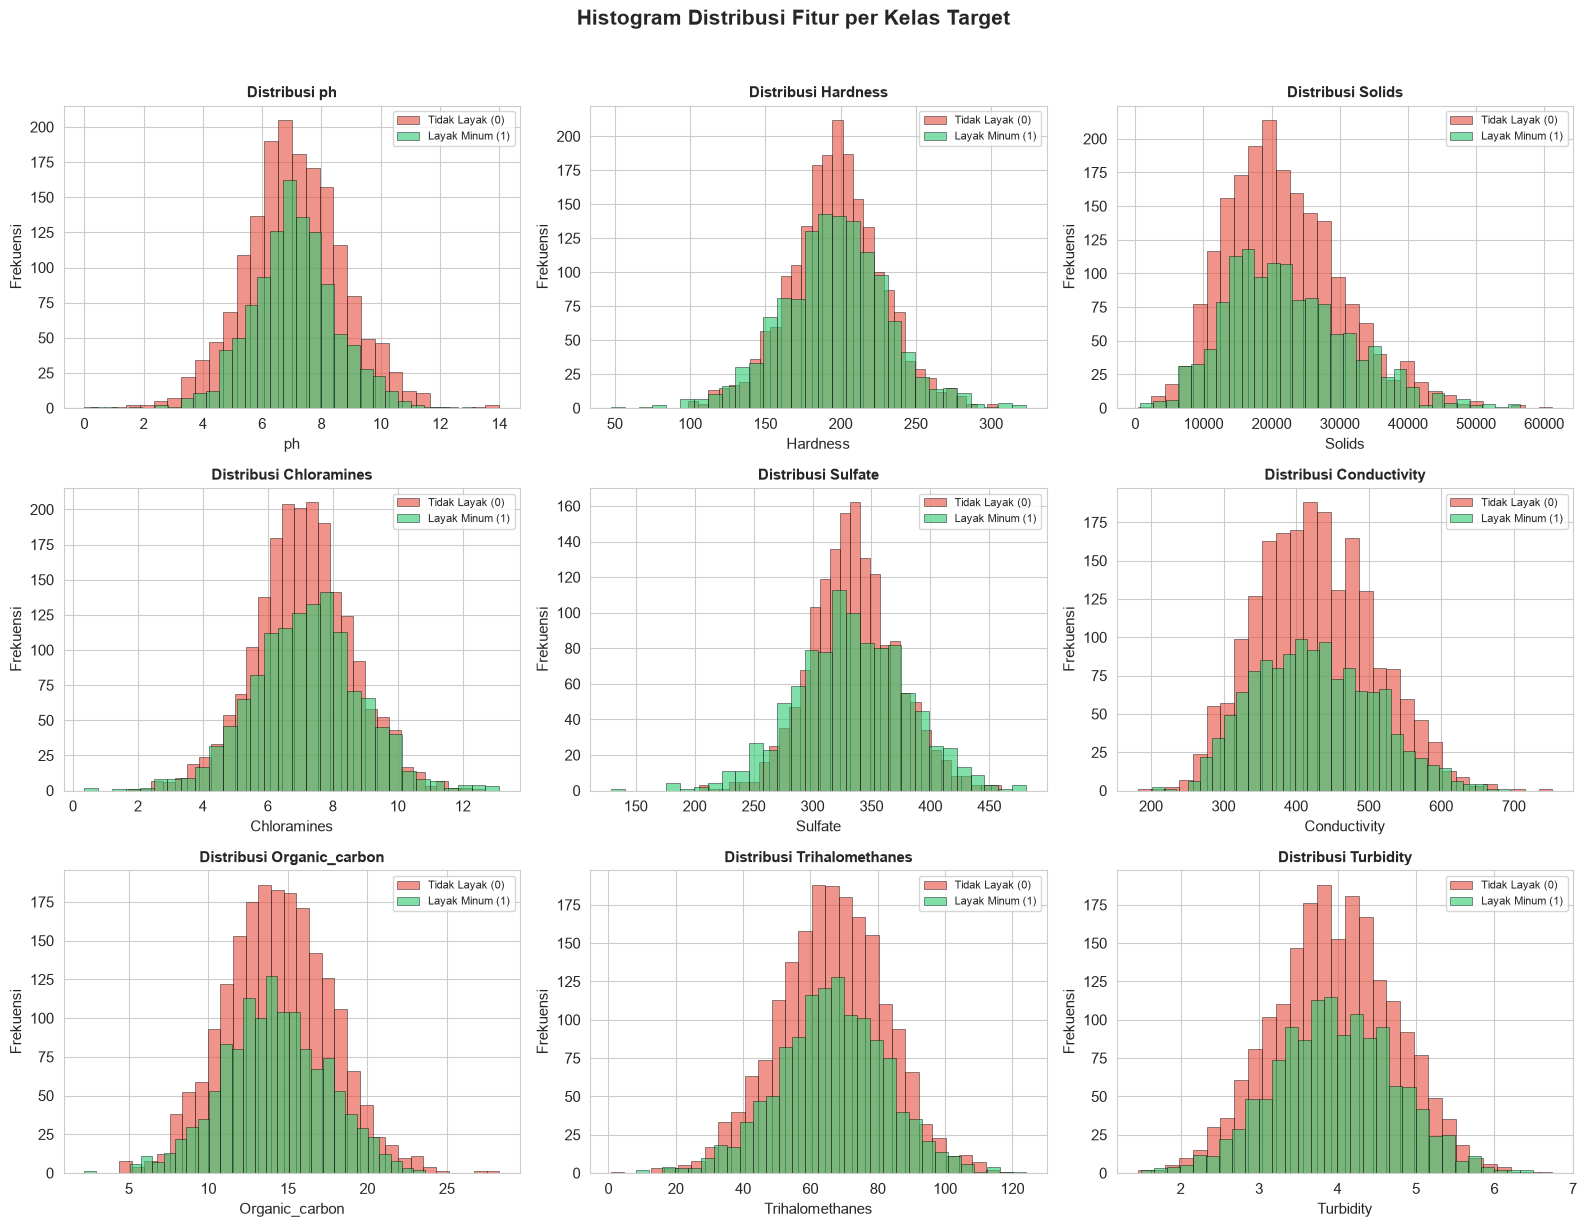

In [9]:
# ============================================================
# Histogram Distribusi Setiap Fitur
# ============================================================
features = df.columns.drop('Potability')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # Histogram terpisah per kelas
    axes[i].hist(df[df['Potability'] == 0][col].dropna(), bins=30, alpha=0.6,
                 label='Tidak Layak (0)', color='#e74c3c', edgecolor='black', linewidth=0.5)
    axes[i].hist(df[df['Potability'] == 1][col].dropna(), bins=30, alpha=0.6,
                 label='Layak Minum (1)', color='#2ecc71', edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Histogram Distribusi Fitur per Kelas Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.7 Visualisasi Outliers (Boxplot)

Boxplot berguna untuk mengidentifikasi outliers pada setiap fitur. Outliers adalah nilai yang jauh dari mayoritas data dan dapat memengaruhi performa model, terutama pada algoritma yang sensitif terhadap skala seperti SVM dan Logistic Regression.

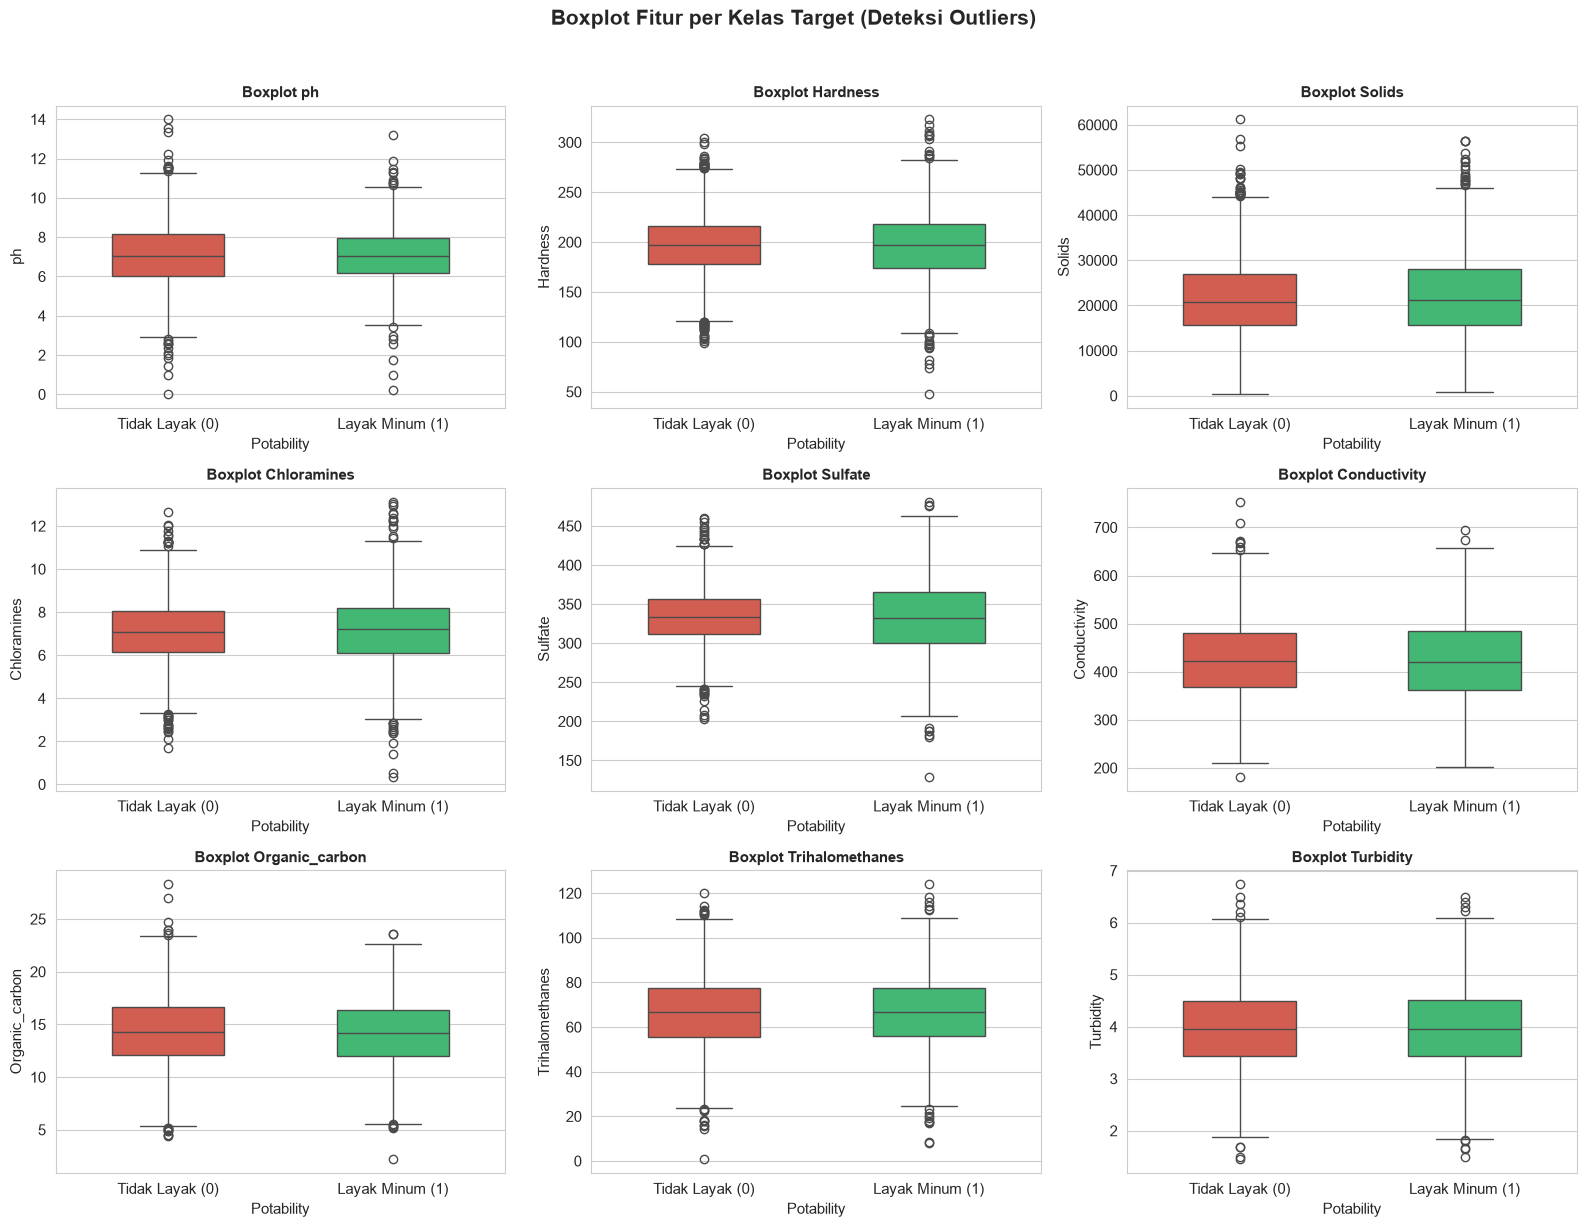

In [10]:
# ============================================================
# Boxplot untuk Deteksi Outliers
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Potability', y=col, hue='Potability', ax=axes[i],
                palette=['#e74c3c', '#2ecc71'], width=0.5, legend=False)
    axes[i].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Potability')
    axes[i].set_xticklabels(['Tidak Layak (0)', 'Layak Minum (1)'])

plt.suptitle('Boxplot Fitur per Kelas Target (Deteksi Outliers)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Kuantifikasi Outliers (Metode IQR)
# ============================================================
print('=' * 60)
print('JUMLAH OUTLIERS PER FITUR (Metode IQR)')
print('=' * 60)

outlier_summary = []
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary.append({
        'Fitur': col,
        'Jumlah Outlier': len(outliers),
        'Persentase (%)': round(len(outliers) / df[col].notna().sum() * 100, 2),
        'Batas Bawah': round(lower_bound, 2),
        'Batas Atas': round(upper_bound, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Jumlah Outlier', ascending=False)
outlier_df.set_index('Fitur', inplace=True)
outlier_df

JUMLAH OUTLIERS PER FITUR (Metode IQR)


,Jumlah Outlier,Persentase (%),Batas Bawah,Batas Atas
Fitur,,,,
Hardness,83,2.5300,117.1300,276.3900
Chloramines,61,1.8600,3.1500,11.1000
Solids,47,1.4300,-1832.4200,44831.8700
ph,46,1.6500,3.1400,11.0200
Sulfate,41,1.6400,229.3200,438.3300
Trihalomethanes,33,1.0600,23.6100,109.5800
Organic_carbon,25,0.7600,5.3300,23.3000
Turbidity,19,0.5800,1.8500,6.0900
Conductivity,11,0.3400,191.6500,655.8800


### 1.8 Analisis Korelasi Antar Fitur

Analisis korelasi menggunakan koefisien Pearson menunjukkan hubungan linier antar fitur. Korelasi tinggi antar fitur (multicollinearity) dapat memengaruhi model Logistic Regression.

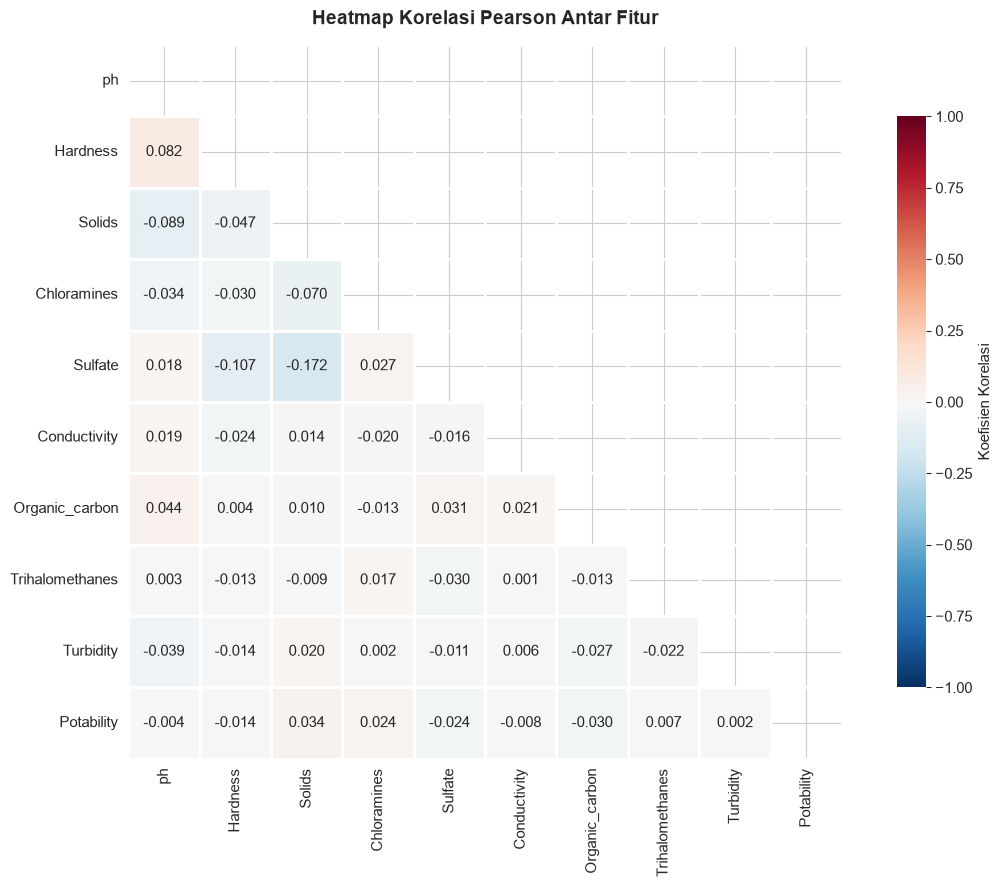

In [12]:
# ============================================================
# Heatmap Korelasi
# ============================================================
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df.corr()

# Mask untuk segitiga atas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            vmin=-1, vmax=1)

ax.set_title('Heatmap Korelasi Pearson Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

KORELASI FITUR TERHADAP TARGET (Potability)


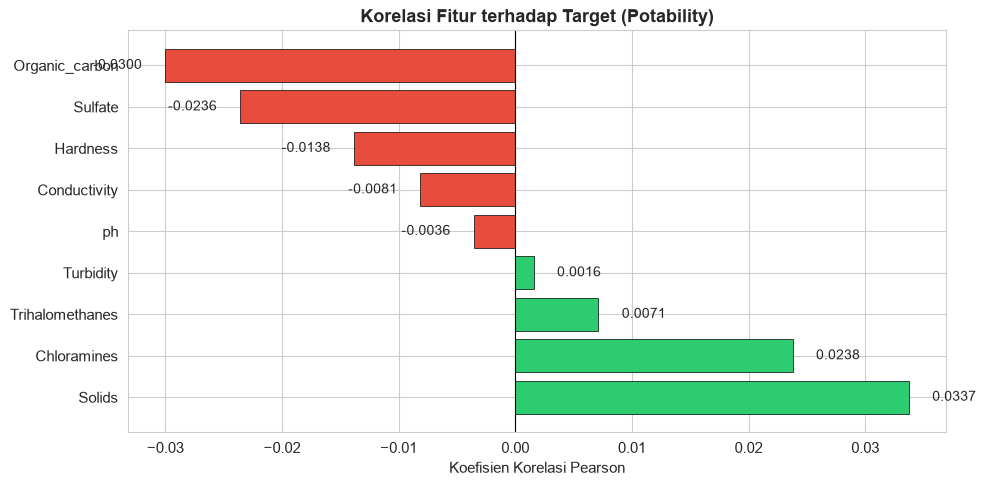

In [13]:
# Korelasi setiap fitur terhadap target
print('=' * 60)
print('KORELASI FITUR TERHADAP TARGET (Potability)')
print('=' * 60)

corr_target = df.corr()['Potability'].drop('Potability').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.002 if val > 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left' if val > 0 else 'right', va='center', fontsize=10)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap Target (Potability)', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')
plt.tight_layout()
plt.show()

### 1.9 Ringkasan Temuan Awal (EDA)

Berikut ringkasan temuan dari tahap Exploratory Data Analysis:

In [14]:
# ============================================================
# Ringkasan Temuan EDA
# ============================================================
print('=' * 60)
print('RINGKASAN TEMUAN EDA')
print('=' * 60)

print(f'''
1. UKURAN DATASET:
   - {df.shape[0]} sampel dengan {df.shape[1]-1} fitur numerik.
   - Semua fitur bertipe numerik (float64), tidak ada fitur kategorik.

2. MISSING VALUES:
   - Kolom 'ph'             : {df['ph'].isnull().sum()} missing ({df['ph'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom 'Sulfate'        : {df['Sulfate'].isnull().sum()} missing ({df['Sulfate'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom 'Trihalomethanes': {df['Trihalomethanes'].isnull().sum()} missing ({df['Trihalomethanes'].isnull().sum()/len(df)*100:.1f}%)
   - Kolom lainnya tidak memiliki missing values.

3. DISTRIBUSI TARGET (IMBALANCED):
   - Kelas 0 (Tidak Layak): {target_counts[0]} sampel ({target_pct[0]:.1f}%)
   - Kelas 1 (Layak Minum): {target_counts[1]} sampel ({target_pct[1]:.1f}%)
   - Dataset bersifat IMBALANCED — kelas "tidak layak" lebih dominan.

4. DISTRIBUSI FITUR:
   - Mayoritas fitur berdistribusi mendekati normal (bell-shaped).
   - Distribusi kedua kelas sangat tumpang tindih (overlapping),
     mengindikasikan tidak ada fitur tunggal yang menjadi pembeda kuat.

5. OUTLIERS:
   - Beberapa fitur memiliki outliers (terlihat pada boxplot).
   - Outliers akan ditangani secara implisit oleh standardisasi dan
     pemilihan model yang robust (Random Forest).

6. KORELASI:
   - Korelasi antar fitur sangat rendah (mendekati 0),
     menunjukkan tidak ada multikolinearitas yang signifikan.
   - Korelasi setiap fitur terhadap target juga sangat rendah,
     mengindikasikan bahwa hubungan antara fitur dan target mungkin
     bersifat non-linear atau membutuhkan kombinasi fitur.
''')

RINGKASAN TEMUAN EDA

1. UKURAN DATASET:
   - 3276 sampel dengan 9 fitur numerik.
   - Semua fitur bertipe numerik (float64), tidak ada fitur kategorik.

2. MISSING VALUES:
   - Kolom 'ph'             : 491 missing (15.0%)
   - Kolom 'Sulfate'        : 781 missing (23.8%)
   - Kolom 'Trihalomethanes': 162 missing (4.9%)
   - Kolom lainnya tidak memiliki missing values.

3. DISTRIBUSI TARGET (IMBALANCED):
   - Kelas 0 (Tidak Layak): 1998 sampel (61.0%)
   - Kelas 1 (Layak Minum): 1278 sampel (39.0%)
   - Dataset bersifat IMBALANCED — kelas "tidak layak" lebih dominan.

4. DISTRIBUSI FITUR:
   - Mayoritas fitur berdistribusi mendekati normal (bell-shaped).
   - Distribusi kedua kelas sangat tumpang tindih (overlapping),
     mengindikasikan tidak ada fitur tunggal yang menjadi pembeda kuat.

5. OUTLIERS:
   - Beberapa fitur memiliki outliers (terlihat pada boxplot).
   - Outliers akan ditangani secara implisit oleh standardisasi dan
     pemilihan model yang robust (Random Forest).

6. K

---
## 2. Desain dan Eksperimen (Preprocessing)

Pada tahap ini, kita melakukan persiapan data sebelum dimasukkan ke dalam model machine learning. Langkah-langkah preprocessing meliputi:
1. Handling missing values
2. Pemeriksaan data kategorik & encoding (jika ada)
3. Pemisahan fitur dan target
4. Train-Test Split
5. Normalisasi/Standardisasi fitur

### 2.1 Handling Missing Values

Strategi yang dipilih adalah mengisi missing values dengan **median** masing-masing kolom. Median lebih robust terhadap outliers dibandingkan mean, sehingga lebih tepat digunakan pada data yang mengandung outliers.

In [15]:
# ============================================================
# Handling Missing Values dengan Median
# ============================================================

df_original = df.copy()

cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f'Kolom dengan missing values: {cols_with_missing}\n')

# Menggunakan assignment karena inplace=True deprecated di Pandas 3.x
for col in cols_with_missing:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'  {col:20s} -> {missing_count} nilai diisi dengan median = {median_val:.4f}')

print(f'\nVerifikasi: Total missing values setelah imputasi = {df.isnull().sum().sum()}')

Kolom dengan missing values: ['ph', 'Sulfate', 'Trihalomethanes']

  ph                   -> 491 nilai diisi dengan median = 7.0368
  Sulfate              -> 781 nilai diisi dengan median = 333.0735
  Trihalomethanes      -> 162 nilai diisi dengan median = 66.6225

Verifikasi: Total missing values setelah imputasi = 0


### 2.2 Pemeriksaan Data Kategorik & Encoding

Encoding diperlukan jika terdapat fitur bertipe kategorik (teks/objek). Pada dataset ini, semua fitur sudah bertipe numerik, sehingga encoding tidak diperlukan.

In [16]:
# ============================================================
# Pemeriksaan Tipe Data & Kebutuhan Encoding
# ============================================================
print('Tipe data setiap kolom:')
print(df.dtypes)

# Cek kolom kategorik
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nKolom kategorik ditemukan: {categorical_cols if categorical_cols else "TIDAK ADA"}')
print('\n✅ Semua fitur bertipe numerik. Encoding TIDAK diperlukan.')

Tipe data setiap kolom:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Kolom kategorik ditemukan: TIDAK ADA

✅ Semua fitur bertipe numerik. Encoding TIDAK diperlukan.


### 2.3 Pemisahan Fitur-Target dan Train-Test Split

Data dibagi menjadi:
- **Training set (80%)**: Untuk melatih model
- **Test set (20%)**: Untuk mengevaluasi performa model pada data yang belum pernah dilihat

Parameter `stratify=y` digunakan agar proporsi kelas target tetap sama pada training dan test set.

In [17]:
# ============================================================
# Pemisahan Fitur (X) dan Target (y)
# ============================================================
X = df.drop('Potability', axis=1)
y = df['Potability']

print(f'Dimensi fitur (X) : {X.shape}')
print(f'Dimensi target (y): {y.shape}')

# ============================================================
# Train-Test Split (80:20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Menjaga proporsi kelas tetap sama
)

print(f'\n--- Hasil Train-Test Split ---')
print(f'Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'\nDistribusi target pada Training set:')
print(y_train.value_counts().to_string())
print(f'\nDistribusi target pada Test set:')
print(y_test.value_counts().to_string())

Dimensi fitur (X) : (3276, 9)
Dimensi target (y): (3276,)

--- Hasil Train-Test Split ---
Training set : 2620 sampel (80%)
Test set     : 656 sampel (20%)

Distribusi target pada Training set:
Potability
0    1598
1    1022

Distribusi target pada Test set:
Potability
0    400
1    256


### 2.4 Normalisasi/Standardisasi Fitur

**StandardScaler** digunakan untuk mentransformasi setiap fitur agar memiliki **mean = 0** dan **standar deviasi = 1**. Hal ini penting karena:
- **Logistic Regression** dan **SVM** sensitif terhadap skala fitur yang berbeda
- Fitur dengan skala besar bisa mendominasi perhitungan jarak

> ⚠️ **Penting:** Scaler di-*fit* hanya pada data training, kemudian di-*transform* pada data training dan testing untuk mencegah **data leakage**.

In [18]:
# ============================================================
# Standardisasi Fitur (StandardScaler)
# ============================================================
scaler = StandardScaler()

# Fit pada training data, kemudian transform keduanya
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame untuk kemudahan inspeksi
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Statistik setelah standardisasi (Training set):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))
print('\n✅ Standardisasi berhasil. Mean ≈ 0, Std ≈ 1.')

Statistik setelah standardisasi (Training set):
         ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
mean 0.0000   -0.0000  0.0000       0.0000   0.0000        0.0000   
std  1.0002    1.0002  1.0002       1.0002   1.0002        1.0002   

      Organic_carbon  Trihalomethanes  Turbidity  
mean         -0.0000          -0.0000    -0.0000  
std           1.0002           1.0002     1.0002  

✅ Standardisasi berhasil. Mean ≈ 0, Std ≈ 1.


---
## 3. Pengembangan Model

Kita akan mengimplementasikan dan membandingkan **3 algoritma klasifikasi**:

| No | Algoritma | Jenis | Kelebihan |
|---|---|---|---|
| 1 | Logistic Regression | Linear | Sederhana, interpretable, cepat |
| 2 | Random Forest | Ensemble (Bagging) | Robust, menangani non-linearitas |
| 3 | Support Vector Machine (SVM) | Kernel-based | Efektif di high-dimensional space |

### 3.1 Model 1: Logistic Regression

**Logistic Regression** adalah model linear yang memprediksi probabilitas kelas menggunakan fungsi sigmoid.

**Hyperparameter yang digunakan:**
- `C=1.0`: Parameter regularisasi (inverse). Semakin kecil C, semakin kuat regularisasi.
- `solver='lbfgs'`: Algoritma optimasi yang cocok untuk dataset berukuran kecil-menengah.
- `max_iter=1000`: Jumlah iterasi maksimum untuk konvergensi.
- `random_state=42`: Untuk reprodusibilitas hasil.

In [19]:
# ============================================================
# Model 1: Logistic Regression
# ============================================================

assert not np.any(np.isnan(X_train_scaled)), 'X_train masih mengandung NaN!'
assert not np.any(np.isnan(X_test_scaled)), 'X_test masih mengandung NaN!'

lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression berhasil dilatih.')
print(f'   Jumlah iterasi konvergensi: {lr_model.n_iter_[0]}')

Logistic Regression berhasil dilatih.
   Jumlah iterasi konvergensi: 3


### 3.2 Model 2: Random Forest

**Random Forest** adalah ensemble method yang membangun banyak Decision Tree dan menggabungkan hasilnya melalui majority voting.

**Hyperparameter yang digunakan:**
- `n_estimators=200`: Jumlah pohon keputusan (semakin banyak, semakin stabil).
- `max_depth=15`: Kedalaman maksimum tiap pohon (membatasi overfitting).
- `min_samples_split=5`: Minimum sampel untuk split internal.
- `min_samples_leaf=2`: Minimum sampel pada setiap leaf node.
- `random_state=42`: Untuk reprodusibilitas.

In [20]:
# ============================================================
# Model 2: Random Forest
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=200,       # Jumlah pohon
    max_depth=15,           # Kedalaman maksimum
    min_samples_split=5,    # Min sampel untuk split
    min_samples_leaf=2,     # Min sampel di leaf
    random_state=42,
    n_jobs=-1               # Gunakan semua CPU core
)

# Training (Random Forest tidak memerlukan data yang di-scale,
# namun kita tetap menggunakan data yang sudah di-scale agar konsisten)
rf_model.fit(X_train_scaled, y_train)

# Prediksi
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print('✅ Random Forest berhasil dilatih.')
print(f'   Jumlah pohon: {rf_model.n_estimators}')
print(f'   Jumlah fitur: {rf_model.n_features_in_}')

✅ Random Forest berhasil dilatih.
   Jumlah pohon: 200
   Jumlah fitur: 9


### 3.3 Model 3: Support Vector Machine (SVM)

**SVM** mencari hyperplane optimal yang memisahkan dua kelas dengan margin maksimum. Dengan kernel RBF, SVM dapat menangani data yang tidak terpisah secara linear.

**Hyperparameter yang digunakan:**
- `C=1.0`: Parameter regularisasi. Mengontrol trade-off antara margin dan misclassification.
- `kernel='rbf'`: Radial Basis Function — kernel non-linear yang umum digunakan.
- `gamma='scale'`: Parameter kernel RBF, dihitung otomatis berdasarkan fitur.
- `probability=True`: Mengaktifkan estimasi probabilitas (diperlukan untuk ROC-AUC).

In [21]:
# ============================================================
# Model 3: Support Vector Machine (SVM)
# ============================================================
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print('SVM berhasil dilatih.')
print(f'   Kernel         : {svm_model.kernel}')
print(f'   Jumlah support vectors: {svm_model.n_support_.sum()}')

SVM berhasil dilatih.
   Kernel         : rbf
   Jumlah support vectors: 1958


---
## 4. Hasil Eksperimen dan Analisis

Pada tahap ini, kita mengevaluasi performa ketiga model menggunakan metrik klasifikasi standar dan membandingkan hasilnya secara visual.

### 4.1 Evaluasi Metrik Klasifikasi

Metrik yang digunakan:
- **Accuracy**: Persentase prediksi yang benar secara keseluruhan
- **Precision**: Dari yang diprediksi positif, berapa yang benar-benar positif
- **Recall**: Dari yang sebenarnya positif, berapa yang berhasil terdeteksi
- **F1-Score**: Harmonic mean antara Precision dan Recall
- **ROC-AUC**: Area under the ROC curve — kemampuan model membedakan kelas

In [22]:
# ============================================================
# Fungsi untuk Menghitung Semua Metrik
# ============================================================
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = [
    evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob),
    evaluate_model('Random Forest', y_test, rf_pred, rf_prob),
    evaluate_model('SVM (RBF Kernel)', y_test, svm_pred, svm_prob)
]

results_df = pd.DataFrame(results).set_index('Model')

print('=' * 70)
print('PERBANDINGAN METRIK EVALUASI KETIGA MODEL')
print('=' * 70)
results_df

PERBANDINGAN METRIK EVALUASI KETIGA MODEL


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6098,0.0000,0.0000,0.0000,0.5481
Random Forest,0.6723,0.7071,0.2734,0.3944,0.6613
SVM (RBF Kernel),0.6707,0.7041,0.2695,0.3898,0.6487


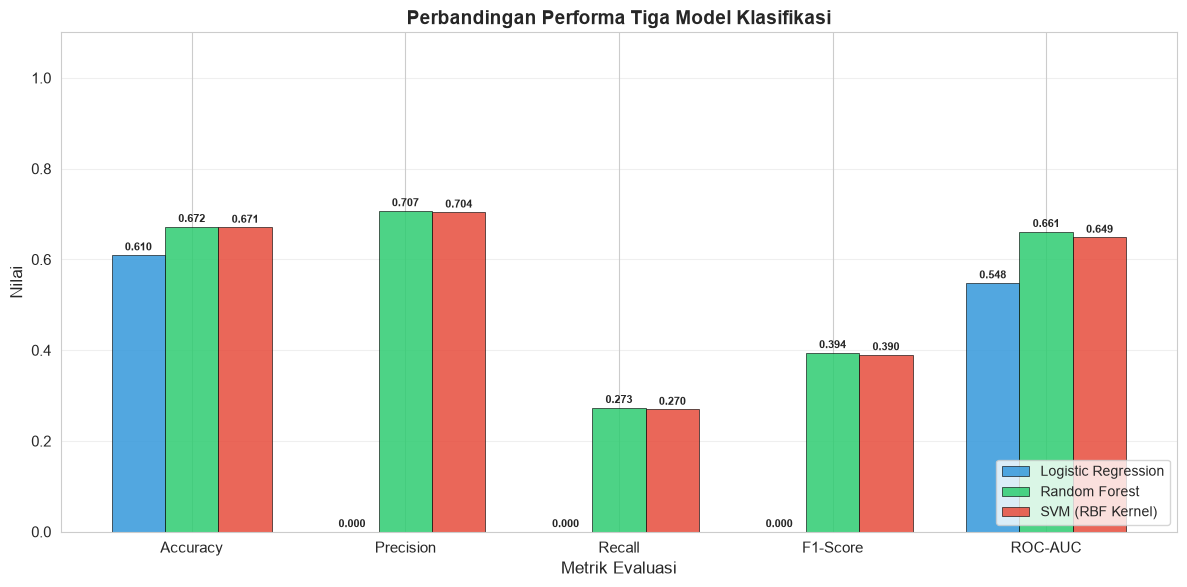

In [23]:
# ============================================================
# Visualisasi Perbandingan Metrik
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names = results_df.index.tolist()

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = results_df.loc[model_name, metrics].values
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    # Tambahkan label nilai
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Perbandingan Performa Tiga Model Klasifikasi', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Classification Report Detail

Classification report memberikan detail Precision, Recall, dan F1-Score per kelas.

In [24]:
# ============================================================
# Classification Report untuk Setiap Model
# ============================================================
models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('SVM (RBF Kernel)', svm_pred)
]

target_names = ['Tidak Layak (0)', 'Layak Minum (1)']

for name, pred in models_info:
    print('=' * 60)
    print(f'Classification Report: {name}')
    print('=' * 60)
    print(classification_report(y_test, pred, target_names=target_names))
    print()

Classification Report: Logistic Regression
                 precision    recall  f1-score   support

Tidak Layak (0)       0.61      1.00      0.76       400
Layak Minum (1)       0.00      0.00      0.00       256

       accuracy                           0.61       656
      macro avg       0.30      0.50      0.38       656
   weighted avg       0.37      0.61      0.46       656


Classification Report: Random Forest
                 precision    recall  f1-score   support

Tidak Layak (0)       0.67      0.93      0.78       400
Layak Minum (1)       0.71      0.27      0.39       256

       accuracy                           0.67       656
      macro avg       0.69      0.60      0.58       656
   weighted avg       0.68      0.67      0.63       656


Classification Report: SVM (RBF Kernel)
                 precision    recall  f1-score   support

Tidak Layak (0)       0.66      0.93      0.77       400
Layak Minum (1)       0.70      0.27      0.39       256

       accuracy

### 4.3 Confusion Matrix

Confusion Matrix menunjukkan jumlah prediksi yang benar dan salah untuk setiap kelas:
- **True Negative (TN)**: Benar diprediksi Tidak Layak
- **False Positive (FP)**: Salah diprediksi Layak Minum
- **False Negative (FN)**: Salah diprediksi Tidak Layak
- **True Positive (TP)**: Benar diprediksi Layak Minum

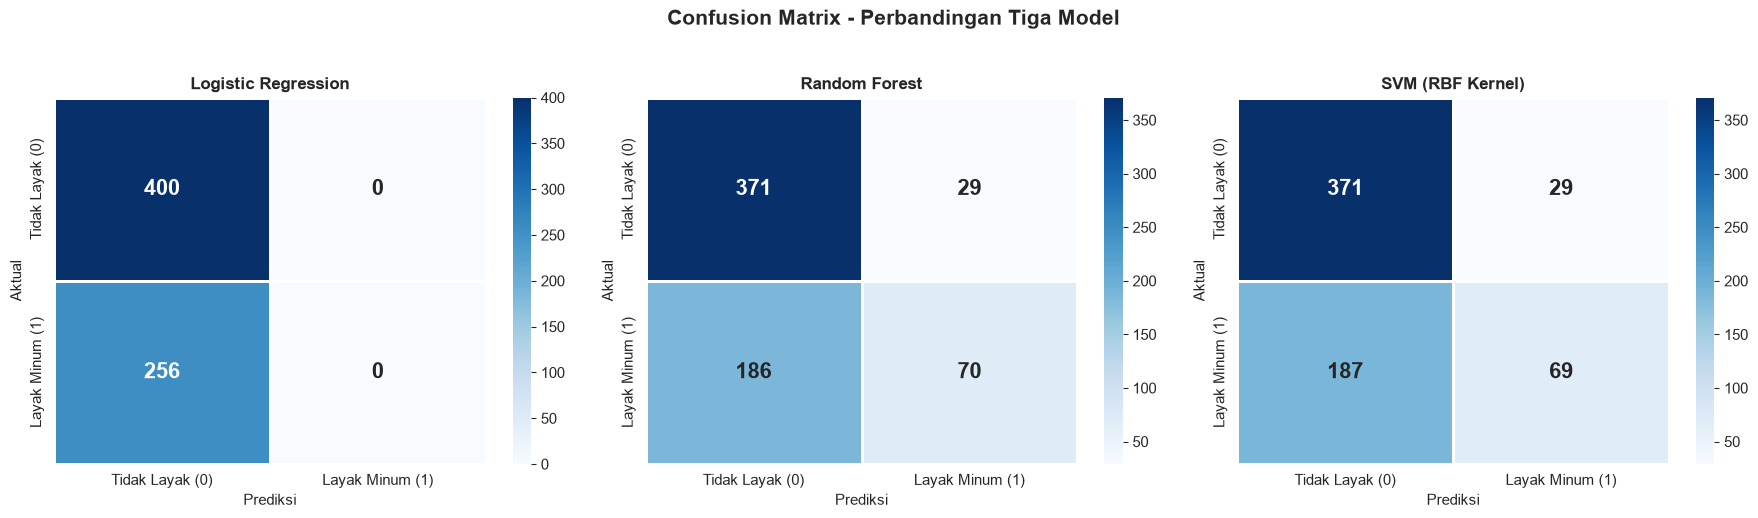

In [25]:
# ============================================================
# Confusion Matrix untuk Ketiga Model
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_pred = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('SVM (RBF Kernel)', svm_pred)
]

for ax, (name, pred) in zip(axes, models_pred):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Layak (0)', 'Layak Minum (1)'],
                yticklabels=['Tidak Layak (0)', 'Layak Minum (1)'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 16, 'fontweight': 'bold'})
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.suptitle('Confusion Matrix - Perbandingan Tiga Model', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4.4 Kurva ROC (Receiver Operating Characteristic)

Kurva ROC menggambarkan trade-off antara True Positive Rate (Recall) dan False Positive Rate pada berbagai threshold. Semakin besar area di bawah kurva (AUC), semakin baik kemampuan model membedakan kedua kelas.

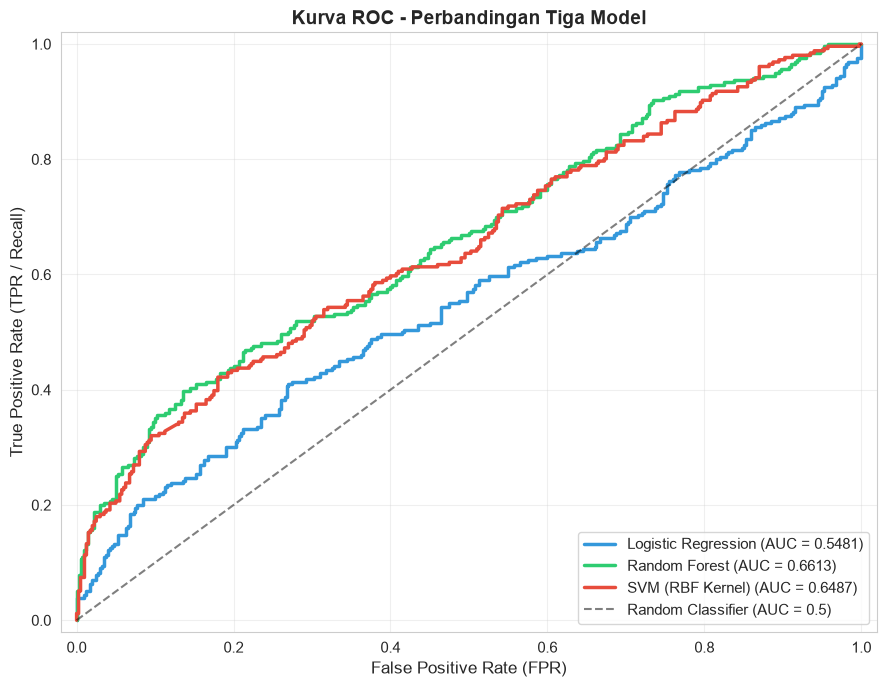

In [26]:
# ============================================================
# Kurva ROC untuk Ketiga Model
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

models_prob = [
    ('Logistic Regression', lr_prob, '#3498db'),
    ('Random Forest', rf_prob, '#2ecc71'),
    ('SVM (RBF Kernel)', svm_prob, '#e74c3c')
]

for name, prob, color in models_prob:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2.5)

# Garis diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('Kurva ROC - Perbandingan Tiga Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

### 4.5 Feature Importance (Model Terbaik)

Feature Importance menunjukkan kontribusi relatif setiap fitur dalam prediksi model. Kita menggunakan **Random Forest** karena model ini menyediakan feature importance bawaan berdasarkan rata-rata penurunan impurity (Gini importance).

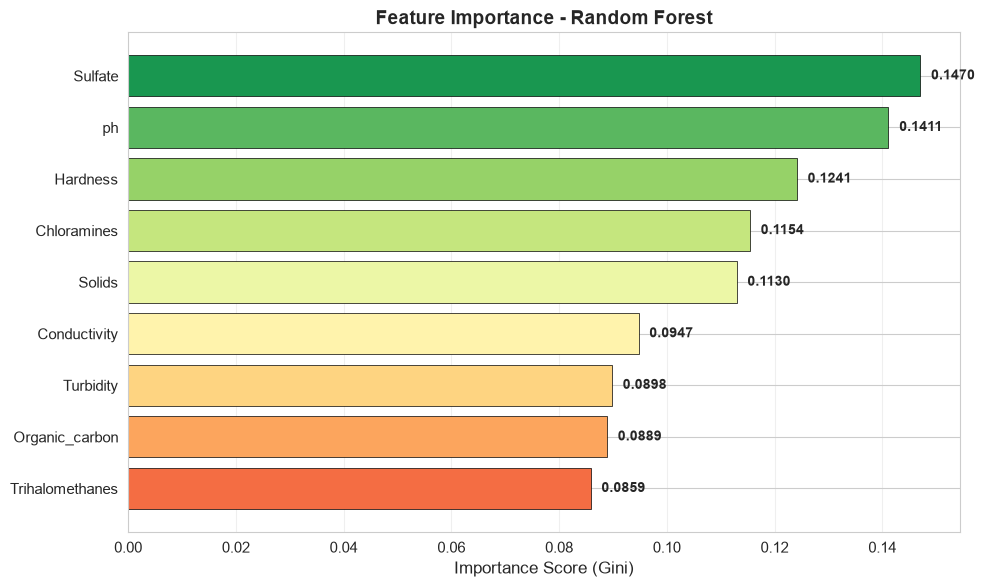


Ranking Feature Importance:
  1. Sulfate                   → 0.1470
  2. ph                        → 0.1411
  3. Hardness                  → 0.1241
  4. Chloramines               → 0.1154
  5. Solids                    → 0.1130
  6. Conductivity              → 0.0947
  7. Turbidity                 → 0.0898
  8. Organic_carbon            → 0.0889
  9. Trihalomethanes           → 0.0859


In [27]:
# ============================================================
# Feature Importance dari Random Forest
# ============================================================
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_df)))
bars = ax.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'],
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Importance Score (Gini)', fontsize=12)
ax.set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan ranking
print('\nRanking Feature Importance:')
for rank, (_, row) in enumerate(feat_imp_df.iloc[::-1].iterrows(), 1):
    print(f'  {rank}. {row["Fitur"]:25s} → {row["Importance"]:.4f}')

---
## 5. Diskusi

Pada bagian ini, kita menginterpretasikan hasil eksperimen, mengidentifikasi model terbaik, serta menganalisis kelebihan, kekurangan, dan faktor-faktor yang mempengaruhi performa.

In [28]:
# ============================================================
# DISKUSI DAN INTERPRETASI HASIL
# ============================================================

best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df['F1-Score'].max()
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print('=' * 70)
print('DISKUSI DAN INTERPRETASI HASIL')
print('=' * 70)

print(f'''
--------------------------------------------------------------------
A. RINGKASAN PERFORMA MODEL
--------------------------------------------------------------------
''')
print(results_df.to_string())

print(f'''

--------------------------------------------------------------------
B. MODEL TERBAIK
--------------------------------------------------------------------

Model terbaik berdasarkan F1-Score: **{best_model_name}**
  - F1-Score : {best_f1:.4f}
  - ROC-AUC  : {best_auc:.4f}

F1-Score dipilih sebagai metrik utama karena dataset bersifat imbalanced.
Accuracy saja tidak cukup karena model bisa mendapatkan accuracy tinggi
hanya dengan memprediksi mayoritas kelas (kelas 0).

--------------------------------------------------------------------
C. ANALISIS PER MODEL
--------------------------------------------------------------------

1. LOGISTIC REGRESSION:
   Kelebihan:
   - Sederhana, cepat, dan mudah diinterpretasikan
   - Memberikan koefisien yang menunjukkan pengaruh tiap fitur
   - Cocok sebagai baseline model
   Kekurangan:
   - Hanya dapat menangkap hubungan linear antara fitur dan target
   - Kurang optimal jika hubungan bersifat non-linear
   - Sensitif terhadap outliers dan multikolinearitas

2. RANDOM FOREST:
   Kelebihan:
   - Dapat menangkap hubungan non-linear dan interaksi antar fitur
   - Robust terhadap outliers dan noise
   - Menyediakan feature importance bawaan
   - Mengurangi overfitting melalui ensemble averaging
   Kekurangan:
   - Lebih sulit diinterpretasikan (black-box)
   - Membutuhkan lebih banyak sumber daya komputasi
   - Cenderung bias terhadap kelas mayoritas pada data imbalanced

3. SVM (RBF KERNEL):
   Kelebihan:
   - Efektif di ruang berdimensi tinggi
   - Kernel RBF mampu menangani batas keputusan non-linear
   - Margin-based: berfokus pada sampel yang sulit (support vectors)
   Kekurangan:
   - Lambat untuk dataset besar
   - Sensitif terhadap pemilihan hyperparameter (C, gamma)
   - Kurang optimal pada data imbalanced tanpa penyesuaian

--------------------------------------------------------------------
D. FAKTOR YANG MEMPENGARUHI PERFORMA
--------------------------------------------------------------------

1. IMBALANCED DATASET:
   Dataset memiliki distribusi kelas yang tidak seimbang
   (kelas 0 lebih banyak dari kelas 1). Hal ini menyebabkan model
   cenderung memprediksi kelas mayoritas, sehingga Recall untuk
   kelas minoritas (kelas 1) menjadi rendah.

2. KORELASI FITUR-TARGET RENDAH:
   Semua fitur memiliki korelasi sangat rendah terhadap target
   (mendekati 0). Ini berarti tidak ada fitur tunggal yang menjadi
   prediktor kuat, sehingga model kesulitan untuk membedakan kelas.

3. DISTRIBUSI FITUR YANG TUMPANG TINDIH:
   Distribusi fitur antara kelas 0 dan 1 sangat mirip (overlapping),
   seperti terlihat pada histogram. Ini membuat batas keputusan
   (decision boundary) menjadi sulit ditentukan.

4. MISSING VALUES:
   Terdapat missing values yang signifikan pada kolom ph, Sulfate,
   dan Trihalomethanes. Imputasi dengan median mungkin tidak selalu
   merepresentasikan nilai sebenarnya.

--------------------------------------------------------------------
E. REKOMENDASI PENINGKATAN
--------------------------------------------------------------------

1. Menangani imbalanced class dengan teknik SMOTE atau class_weight.
2. Melakukan hyperparameter tuning dengan GridSearchCV/RandomizedSearchCV.
3. Mencoba feature engineering untuk membuat fitur baru.
4. Menggunakan metode imputasi yang lebih canggih (KNN Imputer).
5. Menerapkan Cross-Validation untuk evaluasi yang lebih robust.
''')

DISKUSI DAN INTERPRETASI HASIL

--------------------------------------------------------------------
A. RINGKASAN PERFORMA MODEL
--------------------------------------------------------------------

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.6098     0.0000  0.0000    0.0000   0.5481
Random Forest          0.6723     0.7071  0.2734    0.3944   0.6613
SVM (RBF Kernel)       0.6707     0.7041  0.2695    0.3898   0.6487


--------------------------------------------------------------------
B. MODEL TERBAIK
--------------------------------------------------------------------

Model terbaik berdasarkan F1-Score: **Random Forest**
  - F1-Score : 0.3944
  - ROC-AUC  : 0.6613

F1-Score dipilih sebagai metrik utama karena dataset bersifat imbalanced.
Accuracy saja tidak cukup karena model bisa mendapatkan accuracy tinggi
hanya dengan memprediksi mayoritas kelas (kelas 0).

-----

---
## Kesimpulan

Proyek ini berhasil mengimplementasikan tiga algoritma klasifikasi (Logistic Regression, Random Forest, dan SVM) untuk memprediksi kualitas air berdasarkan parameter fisikokimia. Hasil eksperimen menunjukkan bahwa semua model menghadapi tantangan yang sama akibat rendahnya korelasi fitur terhadap target dan distribusi kelas yang tidak seimbang. Meskipun demikian, proyek ini memberikan pemahaman yang komprehensif tentang pipeline machine learning mulai dari EDA hingga evaluasi model.